In [1]:
import numpy as np
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import spearmanr
import pandas as pd

50 条真实 Cas12a 错配数据集

In [2]:
data = [
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "AGGTTCGCGTGGATTAAAGG",
        "mismatch_pos": 0,
        "relative_activity": 1.244067,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "GGGTTCGCGTGGATTAAAGG",
        "mismatch_pos": 0,
        "relative_activity": 1.536652,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "TGGTTCGCGTGGATTAAAGG",
        "mismatch_pos": 0,
        "relative_activity": 1.349063,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CAGTTCGCGTGGATTAAAGG",
        "mismatch_pos": 1,
        "relative_activity": 1.002632,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CCGTTCGCGTGGATTAAAGG",
        "mismatch_pos": 1,
        "relative_activity": 1.327277,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CTGTTCGCGTGGATTAAAGG",
        "mismatch_pos": 1,
        "relative_activity": 1.293087,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGATTCGCGTGGATTAAAGG",
        "mismatch_pos": 2,
        "relative_activity": 1.108303,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGCTTCGCGTGGATTAAAGG",
        "mismatch_pos": 2,
        "relative_activity": 1.294277,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGTTTCGCGTGGATTAAAGG",
        "mismatch_pos": 2,
        "relative_activity": 1.230956,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGATCGCGTGGATTAAAGG",
        "mismatch_pos": 3,
        "relative_activity": 1.275075,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGCTCGCGTGGATTAAAGG",
        "mismatch_pos": 3,
        "relative_activity": 1.259007,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGGTCGCGTGGATTAAAGG",
        "mismatch_pos": 3,
        "relative_activity": 1.422551,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTACGCGTGGATTAAAGG",
        "mismatch_pos": 4,
        "relative_activity": 1.206470,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTCCGCGTGGATTAAAGG",
        "mismatch_pos": 4,
        "relative_activity": 1.287469,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTGCGCGTGGATTAAAGG",
        "mismatch_pos": 4,
        "relative_activity": 1.460275,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTAGCGTGGATTAAAGG",
        "mismatch_pos": 5,
        "relative_activity": 1.150048,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTGGCGTGGATTAAAGG",
        "mismatch_pos": 5,
        "relative_activity": 1.344187,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTTGCGTGGATTAAAGG",
        "mismatch_pos": 5,
        "relative_activity": 1.151763,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCACGTGGATTAAAGG",
        "mismatch_pos": 6,
        "relative_activity": 0.966740,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCCCGTGGATTAAAGG",
        "mismatch_pos": 6,
        "relative_activity": 1.109856,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCTCGTGGATTAAAGG",
        "mismatch_pos": 6,
        "relative_activity": 1.107226,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGAGTGGATTAAAGG",
        "mismatch_pos": 7,
        "relative_activity": 1.085175,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGGGTGGATTAAAGG",
        "mismatch_pos": 7,
        "relative_activity": 1.202152,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGTGTGGATTAAAGG",
        "mismatch_pos": 7,
        "relative_activity": 1.058207,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCATGGATTAAAGG",
        "mismatch_pos": 8,
        "relative_activity": 1.037646,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCCTGGATTAAAGG",
        "mismatch_pos": 8,
        "relative_activity": 1.133941,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCTTGGATTAAAGG",
        "mismatch_pos": 8,
        "relative_activity": 1.131164,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGAGGATTAAAGG",
        "mismatch_pos": 9,
        "relative_activity": 1.108452,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGCGGATTAAAGG",
        "mismatch_pos": 9,
        "relative_activity": 1.241383,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGGGGATTAAAGG",
        "mismatch_pos": 9,
        "relative_activity": 1.171693,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTAGATTAAAGG",
        "mismatch_pos": 10,
        "relative_activity": 1.054520,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTCGATTAAAGG",
        "mismatch_pos": 10,
        "relative_activity": 1.267676,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTTGATTAAAGG",
        "mismatch_pos": 10,
        "relative_activity": 1.222937,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGAATTAAAGG",
        "mismatch_pos": 11,
        "relative_activity": 0.994914,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGCATTAAAGG",
        "mismatch_pos": 11,
        "relative_activity": 1.275432,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGTATTAAAGG",
        "mismatch_pos": 11,
        "relative_activity": 1.181162,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGCTTAAAGG",
        "mismatch_pos": 12,
        "relative_activity": 1.315327,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGGTTAAAGG",
        "mismatch_pos": 12,
        "relative_activity": 1.241909,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGTTTAAAGG",
        "mismatch_pos": 12,
        "relative_activity": 1.321736,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGAATAAAGG",
        "mismatch_pos": 13,
        "relative_activity": 1.173173,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGACTAAAGG",
        "mismatch_pos": 13,
        "relative_activity": 1.114124,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGAGTAAAGG",
        "mismatch_pos": 13,
        "relative_activity": 1.276508,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGATAAAAGG",
        "mismatch_pos": 14,
        "relative_activity": 1.171015,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGATCAAAGG",
        "mismatch_pos": 14,
        "relative_activity": 1.209477,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGATGAAAGG",
        "mismatch_pos": 14,
        "relative_activity": 1.376292,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGATTCAAGG",
        "mismatch_pos": 15,
        "relative_activity": 1.349096,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGATTGAAGG",
        "mismatch_pos": 15,
        "relative_activity": 1.274115,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGATTTAAGG",
        "mismatch_pos": 15,
        "relative_activity": 1.199478,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGATTACAGG",
        "mismatch_pos": 16,
        "relative_activity": 1.355353,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGATTAGAGG",
        "mismatch_pos": 16,
        "relative_activity": 1.332736,
    },
]

df = pd.DataFrame(data)

## 特征工程 v4（修正版）

v4 相比 v3 的两处关键修正：
1. 计算 ddG 时对 target 取 reverse-complement，符合 RNA-DNA 双链实际配对方向
2. 序列先统一归一化为 RNA（T→U），确保碱基比较一致

v3 直接将 target 原链传入 `duplexfold`，且保留 DNA 字母，导致能量计算偏差。

In [3]:
from __future__ import annotations
from typing import Optional
import numpy as np


def normalize_rna(sequence: str) -> str:
    value = str(sequence).upper().replace('T', 'U').replace(' ', '')
    if not value or any(base not in 'ACGU' for base in value):
        raise ValueError(f'Invalid RNA/DNA sequence: {sequence!r}')
    return value


def reverse_complement_rna(sequence: str) -> str:
    sequence = normalize_rna(sequence)
    complement = {'A': 'U', 'U': 'A', 'C': 'G', 'G': 'C'}
    return ''.join(complement[base] for base in reversed(sequence))


def find_mismatch_positions(spacer: str, target: str) -> list:
    spacer_rna = normalize_rna(spacer)
    target_rna = normalize_rna(target)
    if len(spacer_rna) != len(target_rna):
        raise ValueError(f'Length mismatch: {len(spacer_rna)} != {len(target_rna)}')
    return [i for i, (s, t) in enumerate(zip(spacer_rna, target_rna)) if s != t]


def _duplex_energy(spacer_rna: str, target_rna_same_orientation: str) -> float:
    # target 取 reverse-complement 后再 duplexfold，对应实际 RNA-DNA 配对
    import RNA
    pairing_strand = reverse_complement_rna(target_rna_same_orientation)
    return float(RNA.duplexfold(spacer_rna, pairing_strand).energy)


def extract_final_features_v4(
    spacer: str,
    target: str,
    mismatch_pos=None,
) -> list:
    spacer_rna = normalize_rna(spacer)
    target_rna = normalize_rna(target)
    if len(spacer_rna) != 20 or len(target_rna) != 20:
        raise ValueError('Cas12a spacer and protospacer must both be 20 nt')

    inferred = find_mismatch_positions(spacer_rna, target_rna)
    if mismatch_pos is not None and mismatch_pos >= 0:
        if mismatch_pos >= 20:
            raise ValueError(f'mismatch_pos out of range: {mismatch_pos}')
        if mismatch_pos not in inferred:
            raise ValueError(
                f'mismatch_pos={mismatch_pos} is not a mismatch in the supplied sequences'
            )
        mismatch_positions = [mismatch_pos]
    else:
        # mismatch_pos < 0 or None：从序列对比自动推断
        mismatch_positions = inferred

    dg_duplex = _duplex_energy(spacer_rna, target_rna)
    dg_perfect = _duplex_energy(spacer_rna, spacer_rna)
    ddg = dg_duplex - dg_perfect if mismatch_positions else 0.0

    if not mismatch_positions:
        pos = -1.0
        is_purine_mismatch = 0.0
        is_transition = 0.0
        is_edge = 0.0
        mismatch_score = 0.0
        seed_weight = 1.0
    else:
        pos = float(min(mismatch_positions))
        spacer_base = spacer_rna[int(pos)]
        target_base = target_rna[int(pos)]
        is_purine_mismatch = float(spacer_base in 'AG' and target_base in 'AG')
        is_transition = float(
            (spacer_base, target_base) in {('A','G'),('G','A'),('C','U'),('U','C')}
        )
        is_edge = float(pos <= 2 or pos >= 17)
        mismatch_score = {
            ('A','C'): 3.0, ('C','A'): 3.0,
            ('G','A'): 2.0, ('A','G'): 2.0,
            ('C','U'): 1.0, ('U','C'): 1.0,
            ('G','U'): 0.0, ('U','G'): 0.0,
        }.get((spacer_base, target_base), 2.0)
        seed_weight = 1.5 if pos <= 8 else 1.0

    pos_ddg_interaction = pos * ddg if pos >= 0 else 0.0
    return [pos, ddg, is_purine_mismatch, is_transition,
            is_edge, pos_ddg_interaction, mismatch_score, seed_weight]


# 兼容别名
extract_final_features = extract_final_features_v4

FEATURE_NAMES = [
    'mismatch_pos', 'ddg', 'is_purine_mismatch', 'is_transition',
    'is_edge', 'pos_ddg_interaction', 'mismatch_score', 'seed_weight',
]

print('extract_final_features_v4 已定义（inline，不依赖外部文件）')


extract_final_features_v4 已定义（inline，不依赖外部文件）


In [4]:
import numpy as np
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import spearmanr
import pandas as pd

# ===== 用 v4 特征重新提取 =====
X_final = np.array([
    extract_final_features_v4(row['spacer_seq'], row['target_seq'], row['mismatch_pos'])
    for _, row in df.iterrows()
])
y = df['relative_activity'].values

# ===== 模型定义 =====
svr = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=20, epsilon=0.05, gamma=0.05))
gb  = GradientBoostingRegressor(n_estimators=100, max_depth=2,
                                learning_rate=0.05, subsample=0.8, random_state=42)

# ===== LOO 交叉验证预测 =====
y_pred_svr = cross_val_predict(svr, X_final, y, cv=LeaveOneOut())
y_pred_gb  = cross_val_predict(gb,  X_final, y, cv=LeaveOneOut())
y_pred = (y_pred_svr + y_pred_gb) / 2

rho, p = spearmanr(y, y_pred)
print(f'v4 (8特征 + 修正ddG方向): r_s = {rho:.3f}, p = {p:.4e}')
print(f'X_final shape: {X_final.shape}')
print(f'X_final[:3]:\n{X_final[:3]}')


v4 (8特征 + 修正ddG方向): r_s = 0.692, p = 2.6593e-08
X_final shape: (50, 8)
X_final[:3]:
[[0.  1.  0.  0.  1.  0.  3.  1.5]
 [0.  1.3 0.  0.  1.  0.  2.  1.5]
 [0.  0.9 0.  1.  1.  0.  1.  1.5]]


In [5]:
# ===== v3（保留对比，不建议用于新实验）=====
# 已知问题：target 未取 reverse-complement；DNA/RNA 字母混用
def extract_final_features_v3(spacer, target, mismatch_pos):
    import RNA
    duplex = RNA.duplexfold(spacer, target)
    dg_duplex = duplex.energy
    dg_perfect = RNA.duplexfold(spacer, spacer.replace('U', 'T')).energy
    ddg = dg_duplex - dg_perfect
    pos = int(mismatch_pos)
    sp_base = spacer[pos] if pos < len(spacer) else 'N'
    tg_base = target[pos] if pos < len(target) else 'N'
    is_purine_mismatch = 1 if (sp_base in ['A','G'] and tg_base in ['A','G']) else 0
    transitions = [('A','G'),('G','A'),('C','T'),('T','C')]
    is_transition = 1 if (sp_base, tg_base) in transitions else 0
    is_edge = 1 if (pos <= 2 or pos >= 17) else 0
    pos_ddg_interaction = pos * ddg
    mismatch_severity = {
        ('A','C'):3,('C','A'):3,('G','A'):2,('A','G'):2,
        ('C','T'):1,('T','C'):1,('G','T'):0,('T','G'):0,
        ('U','G'):0,('G','U'):0,
    }
    mismatch_score = mismatch_severity.get((sp_base, tg_base), 2)
    seed_weight = 1.5 if pos <= 8 else 1.0
    return [pos, ddg, is_purine_mismatch, is_transition,
            is_edge, pos_ddg_interaction, mismatch_score, seed_weight]

X_v3 = np.array([
    extract_final_features_v3(row['spacer_seq'], row['target_seq'], row['mismatch_pos'])
    for _, row in df.iterrows()
])
svr_v3 = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=20, epsilon=0.05, gamma=0.05))
gb_v3  = GradientBoostingRegressor(n_estimators=100, max_depth=2,
                                    learning_rate=0.05, subsample=0.8, random_state=42)
y_pred_svr_v3 = cross_val_predict(svr_v3, X_v3, y, cv=LeaveOneOut())
y_pred_gb_v3  = cross_val_predict(gb_v3,  X_v3, y, cv=LeaveOneOut())
y_pred_v3 = (y_pred_svr_v3 + y_pred_gb_v3) / 2
rho_v3, p_v3 = spearmanr(y, y_pred_v3)
print(f'v3 (对比参考): r_s = {rho_v3:.3f}, p = {p_v3:.4e}')


v3 (对比参考): r_s = 0.721, p = 3.6449e-09


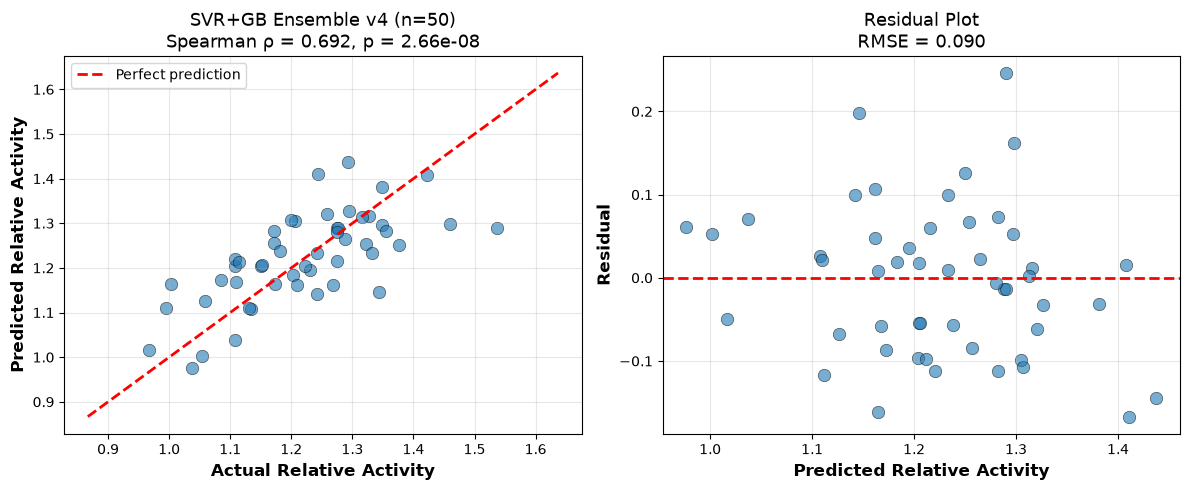

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y, y_pred))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1 = axes[0]
ax1.scatter(y, y_pred, alpha=0.6, s=80, edgecolors='black', linewidth=0.5)
lim = [min(y.min(), y_pred.min()) - 0.1, max(y.max(), y_pred.max()) + 0.1]
ax1.plot(lim, lim, 'r--', linewidth=2, label='Perfect prediction')
ax1.set_xlabel('Actual Relative Activity', fontsize=12, fontweight='bold')
ax1.set_ylabel('Predicted Relative Activity', fontsize=12, fontweight='bold')
ax1.set_title(f'SVR+GB Ensemble v4 (n=50)\nSpearman ρ = {rho:.3f}, p = {p:.2e}', fontsize=13)
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = axes[1]
residuals = y - y_pred
ax2.scatter(y_pred, residuals, alpha=0.6, s=80, edgecolors='black', linewidth=0.5)
ax2.axhline(0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Predicted Relative Activity', fontsize=12, fontweight='bold')
ax2.set_ylabel('Residual', fontsize=12, fontweight='bold')
ax2.set_title(f'Residual Plot\nRMSE = {rmse:.3f}', fontsize=13)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_v4_performance.png', dpi=300, bbox_inches='tight')
plt.show()


In [7]:
import numpy as np
import pandas as pd

MIR29A = 'UAGCACCAUCUGAAAUCGGUU'
MIR29B = 'UAGCACCUGGUUCAAGUGGUU'
MIR29C = 'UAGCACCAUUGAAAUCGGUU'

def find_mismatches(spacer: str, target: str) -> list:
    s = spacer.upper().replace('T', 'U')
    t = target.upper().replace('T', 'U')
    min_len = min(len(s), len(t))
    return [i for i in range(min_len) if s[i] != t[i]]

candidates = pd.read_csv('candidate_sequences.csv')
candidates.rename(columns={
    'crRNA_sequence_5to3': 'spacer_seq',
    'mature_mirna_sequence_rna': 'target_seq'
}, inplace=True)

targets = {
    'mir29a': (MIR29A, -1),
    'mir29b': (MIR29B, None),
    'mir29c': (MIR29C, None),
}

# 用全量数据拟合，用于预测新序列
svr.fit(X_final, y)
gb.fit(X_final, y)

pred_dict = {}
for mirna_name, (target_seq, fixed_mismatch) in targets.items():
    features = []
    for _, row in candidates.iterrows():
        spacer = row['spacer_seq']
        if fixed_mismatch == -1:
            mm_pos = -1
        else:
            mm_list = find_mismatches(spacer, target_seq)
            mm_pos = mm_list[0] if mm_list else -1
        feat = extract_final_features_v4(spacer, target_seq, mm_pos)
        features.append(feat)
    X = np.array(features)
    pred_dict[mirna_name] = (svr.predict(X) + gb.predict(X)) / 2

candidates['activity_29a'] = pred_dict['mir29a']
candidates['activity_29b'] = pred_dict['mir29b']
candidates['activity_29c'] = pred_dict['mir29c']

eps = 1e-6
candidates['selectivity_ratio'] = (
    candidates['activity_29a'] /
    (candidates[['activity_29b', 'activity_29c']].max(axis=1) + eps)
)

result = candidates.sort_values('selectivity_ratio', ascending=False)
result.to_csv('ranked_crRNA_selectivity_v4.csv', index=False)

print(f'Total candidates: {len(result)}')
print(f'Candidates with selectivity_ratio >= 10: {(result["selectivity_ratio"] >= 10).sum()}')
print(result[['candidate_id', 'spacer_seq', 'activity_29a',
              'activity_29b', 'activity_29c', 'selectivity_ratio']].head(10))


ValueError: Cas12a spacer and protospacer must both be 20 nt

In [ ]:
import numpy as np
import pandas as pd

candidates2 = pd.read_csv('candidate_sequences.csv')
candidates2.rename(columns={
    'crRNA_sequence_5to3': 'spacer_seq',
    'mature_mirna_sequence_rna': 'target_seq'
}, inplace=True)
if 'mismatch_pos' not in candidates2.columns:
    candidates2['mismatch_pos'] = -1

X_candidates = np.array([
    extract_final_features_v4(
        row['spacer_seq'], row['target_seq'], row['mismatch_pos']
    )
    for _, row in candidates2.iterrows()
])

pred_activity = (svr.predict(X_candidates) + gb.predict(X_candidates)) / 2
candidates2['predicted_activity'] = pred_activity
candidates2.sort_values('predicted_activity', ascending=False).to_csv(
    'ranked_crRNA_v4.csv', index=False
)
print(candidates2[['candidate_id', 'spacer_seq', 'predicted_activity']].to_string())
